# Simultaneous - Tank Manifold DAE System Example

The following example is a DAE system adapted from {cite}`koch2024` describing a system of 4 interconnected tanks. The differential states $x_0, ..., x_3$ describe the fluid heights in the tanks and the algebraic variables $y_1, ..., y_4$ denote the flow rate between tanks. A pump sets the flow rate of algebraic variable $y_0$ as a function of the fluid heights $x_0$ and $x_3$. The flow in $y_2$ is reversible. The fluid heights in $x_0$ and $x_1$ are constrained at all times.

The system is shown graphically below:

![FourTank_Koch](../images/FourTank_Koch2024.png)

The DAE describing the evolution of this system in time is given by:

$$
\begin{align}
\frac{dx_0}{dt} &= \frac{1}{\phi_0(x_0)}(y_1 - y_3) \tag{1} \\
\frac{dx_1}{dt} &= \frac{1}{\phi_1(x_1)}(y_2) \tag{2} \\
\frac{dx_2}{dt} &= \frac{1}{\phi_2(x_2)}(y_3 - y_4) \tag{3} \\
\frac{dx_3}{dt} &= \frac{1}{\phi_3(x_3)}(y_4 - y_0) \tag{4} \\
x_0(t) = x_1(t), \quad y_0(t) &= y_1(t) + y_2(t), \quad y_4(t) = a_2\sqrt{x_2(t)} \tag{5} \\
y_0(t) &= C_{pump}x_0x_3, \quad y_3(t) = a_1\sqrt{x_0(t)} \tag{6} \\
y_0(t), y_1(t), y_3(t), y_4(t) &\geq 0 \tag{7}
\end{align}
$$


Where, $\phi_i(x_i)$ describes the area-height profile of the tanks, which is defined by their shape. Let all the area profiles be constant: $\phi_0(x_0)=\frac{1}{10}$, $\phi_1(x_1)=\frac{1}{2}$ $\phi_2(x_2)=2$, $\phi_3(x_3)=10$. The discharge coefficients, $a_1$ and $a_2$, are set at $\frac{1}{10}$, while the pump discharge coefficient, $C_{pump}$, is set at $\frac{1}{5}$. 


In this example, assume the expressions in $(6)$ are unknown. Thus, we would like to learn a neural network mapping from the obsereved height variables $x(t)$ to the unknown flowrates in $(3)$, i.e. $f_{NN}: x(t) \rightarrow (y_0(t), y_3(t))^T$. Therefore, (6) can be rewritten as:

$$
\begin{align}
z(t) = (y_3(t), y_0(t))^T &= f_{NN}(x(t), \theta)  \tag{8} \\
\end{align}
$$


Let's start with the required imports.

In [1]:
%matplotlib inline

import logging
import jax
import numpy as np
import pyomo.environ as pyo
import pyomo.dae as dae
import matplotlib.pyplot as plt

from sindae.problem import ProblemDefinition
from sindae.nn_utils import SimpleMLP
from sindae import generate_data
from sindae.data_utils import extract_instance_data, InstanceData
from sindae.algorithms.smoother import solve_smoother
from sindae.algorithms.pretrain import PretrainConfig, pretrain_mlp
from sindae.algorithms.simultaneous.train import SimultaneousConfig, solve_simultaneous
from sindae.plot_utils import plot_instance_data, plot_training_history
from sindae.algorithms.inference import solve_inference

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logging.getLogger('pyomo').setLevel(logging.ERROR)
logging.getLogger('cyipopt').setLevel(logging.WARNING)
logger = logging.getLogger(__name__)

## Defining A Problem

Before using SiNDAE's solution approaches, you should formulate the DAE you are solving by defining a `ProblemDefinition` class. The problem definition class requires the implementation of 3 methods: `build_trajectory(self, block: pyo.Block, traj_idx: int)` which adds the DAE formulation and constraints to a Pyomo Block, `get_input_vars(self, block: pyo.Block, t)` which returns the list of Pyomo Vars fed into the NN at time $t$, and `get_output_vars(self, block: pyo.Block, t)` which returns a list of Pyomo Vars output by the NN at time $t$. 

With these methods in mind, we can define our `FourTankProblem` by inheriting from `ProblemDefinition`.

Define the DAE problem class and the required `ProblemDefinition` methods. The `build_trajectory()` defines the DAE system, algebraic constraints, and auxiliary constraints / variables using the Pyomo modelling language. For this example problem, we know the true dynamics of our problem (i.e. the $y_0$ and $y_3$ dynamics), so the `true_constraints()` can be defined, allowing synthetic data generation.

In [2]:
class FourTankProblem(ProblemDefinition):
    def __init__(self,
                 ## Additional Args ##
                 params,
                 ## ProblemDefinition Args ##
                 ics, 
                 input_dim, 
                 z_dim, 
                 t_span, 
                 nfe, 
                 ncp, 
                 obs_times = None, 
                 obs_values = None, 
                 obs_dim = None, 
                 aux_vars_dim = None
                 ):
        
        super().__init__(ics, input_dim, z_dim, 
                         t_span, nfe, ncp, obs_times, 
                         obs_values, obs_dim, aux_vars_dim)

        self.params = params 


    def build_trajectory(self, block, traj_idx):
        t0, _ = self.t_span
        x0    = self.ics[traj_idx]
        p     = self.params
        phi   = p['phi']

        block.t    = dae.ContinuousSet(bounds=self.t_span) 
        block.x    = pyo.Var(block.t, range(self.input_dim), initialize=10.0)
        block.z    = pyo.Var(block.t, range(self.z_dim)) # z is the RHS of the equations to be learned by a NN
        block.y    = pyo.Var(block.t, range(self.aux_vars_dim))
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)
        
        ## Differential Equations ##
        @block.Constraint(block.t, range(self.input_dim))
        def diffeq(b, t, s):
            y = [b.y[t, j] for j in range(self.aux_vars_dim)]
            if s == 0:
                # Eqn (1)
                return b.dxdt[t, 0] == (1.0 / phi[0]) * (y[1] - y[3])
            elif s == 1:
                # Eqn (2)
                return b.dxdt[t, 1] == (1.0 / phi[1]) * y[2]
            elif s == 2:
                # Eqn (3)
                return b.dxdt[t, 2] == (1.0 / phi[2]) * (y[3] - y[4])
            else:
                # Eqn (4)
                return b.dxdt[t, 3] == (1.0 / phi[3]) * (y[4] - y[0])


        ## Algebraic constraints ##
        
        # Eqn (5-1)
        @block.Constraint(block.t)
        def height_req(b, t):  
            return b.x[t, 0] == b.x[t, 1]
        
        # Eqn (5-2)
        @block.Constraint(block.t)
        def flow_balance(b, t): 
            return b.y[t, 0] == b.y[t, 1] + b.y[t, 2]

        # Eqn (5-3)
        @block.Constraint(block.t)
        def dis4(b, t):        
            return b.y[t, 4] == p['a2'] * pyo.sqrt(b.x[t, 2])

        # Eqn (6-1)
        @block.Constraint(block.t)
        def pump(b, t):        
            return b.y[t, 0] == b.z[t, 0] # z is the RHS of the equations to be learned by a NN

        # Eqn (6-2)
        @block.Constraint(block.t)
        def dis3(b, t):        
            return b.y[t, 3] == b.z[t, 1] # z is the RHS of the equations to be learned by a NN

        # Eqn (7)
        @block.Constraint(block.t, range(self.aux_vars_dim))
        def flow_lb(b, t, j):
            if j == 2:
                return pyo.Constraint.Skip
            return b.y[t, j] >= 0


        # Initial conditions
        for j in range(1, self.input_dim):
            block.x[t0, j].fix(float(x0[j]))

        # Clamp y_1 at t_0 to avoid under-determined algebraic system at the initial collocation point.
        @block.Constraint()
        def clamp_u1(b): 
            return b.y[t0, 1] == b.y[t0, 0]


    ## Ground Truth ##
    def add_true_output_constraints(self, block: pyo.Block) -> None:
        a1 = self.params['a1']
        cp = self.params['pump_coef']

        @block.Constraint(block.t, range(self.z_dim))
        def true_z(b, t, k):
            if k == 0:
                return b.z[t, 0] == cp * b.x[t, 0] * b.x[t, 3]
            else:
                return b.z[t, 1] == a1 * pyo.sqrt(b.x[t, 0])
            

    def get_input_vars(self, block, t):  
        return [block.x[t, j] for j in range(self.input_dim)]

    def get_output_vars(self, block, t): 
        return [block.z[t, k] for k in range(self.z_dim)]

    def get_aux_vars(self, block, t):    
        return [block.y[t, k] for k in range(self.aux_vars_dim)]

The parameters of this problem are given by the following:

In [3]:
FT_PARAMS = {
    'a1':        0.1,                   # a_1 = 1/10
    'a2':        0.1,                   # a_2 = 1/10
    'pump_coef': 0.2,                   # C_{pump} = 1/5
    'phi':       [0.1, 0.5, 2.0, 10.0], # phi_i = [1/10, 1/2, 2, 10]
}

SEED = 0

Initial conditions for sample trajectories should also be defined. For this example, the $x_0=x_1$ constraint in $(5)$ should be reflected in the ICs. These are the *training* ICs. These will be used for data generation from the ground truth model (since this is a known example), and as state variable initial conditions for the differential system.

In [4]:
## Initial Conditions ##
FT_ICS = np.array([
    [0.75, 0.75, 2.50, 0.60], # traj_0: x_t0 = [x_1, x_2, x_3, x_4]
    [3.10, 3.10, 1.50, 0.50], # traj_1
    [0.90, 0.90, 1.80, 1.10], # traj_2
])

Next, define the observed variable state dimension, $x(t)$, the number of NN modeled variables, $z(t)$, and the number of algebraic variables, $y(t)$.

In [5]:
## Problem dimensions ##
FT_STATE_DIM = 4    # NN input dim
FT_Z_DIM     = 2    # NN output dim
FT_ALG_DIM   = 5    # Algebraic variable dim 


The timespan over which the model should be solved.

In [6]:
## Time span ##
T_SPAN = (0, 400)

In this example, the training data will be generated from a ground truth model with added noise. Therefore, the number of discretization points at which the ground truth model is solved should be specified in the problem definition. Using `generate_data()` will solve the model with the `add_true_output_constraints()` at this discretization scheme. Once the data is generated, the discretization scheme can (and will) be updated for training.

In [7]:
## Discretization for data generation with true model ##
NFE_DATA  = 40
NCP_DATA  = 3

Now we can define the problem instance.

In [8]:
## Define the problem instance ##
problem = FourTankProblem(
    # Additional args
    params=FT_PARAMS,
    # Problem definintion args
    ics=FT_ICS,
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_DATA, 
    ncp=NCP_DATA,
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=FT_ALG_DIM
    )


## Generating training Data

With the problem defined, we can use the `generate_data()` function to generate the synthetic training data.

In [9]:
## Added noise standard deviation ##
NOISE_STD   = np.array([0.5, 0.5, 0.25, 0.05])

## Ground truth observation frequency ##
OBS_EVERY = 4

In [10]:
print('=== 1. Generating data ===')
true_data: InstanceData = generate_data(
    problem=problem, 
    noise_std=NOISE_STD, 
    obs_every=OBS_EVERY, 
    seed=SEED,
)

=== 1. Generating data ===


generate_data: ok / optimal


## Defining the Neural Network

Before pretraining, the NN used to estimate the $z(t)$ terms should be defined. SinDAE, comes equipped with a `SimpleMLP` class as an equinox MLP implementation, which we will be using for this example. To set up your own NN architecture, see [Neural Network Utilities](../api/nn_utils.md).

In [11]:
## Define the NN ##
mlp = SimpleMLP(
    in_size=problem.input_dim,
    out_size=problem.z_dim,
    widths=[32, 32],
    activations=[jax.nn.tanh] * 2,
    key=jax.random.PRNGKey(SEED),
)

## Pretraining the Neural Network 

With the NN defined, the smoothed problem (i.e. with $z(t)$ as a decision variable) can be solved for ($x_{init}, z_{init}$) pretraining pairs. For both the smoothed problem solution and the training, the discretization scheme will be changed to show SiNDAE's discretization flexibility.

In [12]:
## Discretization for the smoothed problem and training ##
NFE_TRAIN = 20
NCP_TRAIN = 3
SMOOTH_COEF = 10

# update the problem's discretization for training
problem.nfe = NFE_TRAIN
problem.ncp = NCP_TRAIN

## Solve the smoothed problem and extract the pretraining pairs ##
smoother_m = solve_smoother(problem, mlp, smooth_coef=SMOOTH_COEF)
smoother_data: InstanceData = extract_instance_data(problem, smoother_m)

=== Building smoother for 3 trajectories (smooth_coef=10) ===
  Smoother: ok / optimal


The `smoothed_data` can now be used with the `pretrain_mlp()` function to warm start the neural network before the training process 

In [13]:
## Pretraining configuration ##
PT_EPOCHS = 200
PT_BS = 32
PT_REG_COEF = 0.01

pretrain_config = PretrainConfig(
    epochs=PT_EPOCHS, 
    batch_size=PT_BS, 
    reg_coef=PT_REG_COEF
)

print('=== 3. Pretraining MLP ===')
mlp = pretrain_mlp(mlp, smoother_data, pretrain_config)

=== 3. Pretraining MLP ===


## Neural Network Training - Simultaneous Approach 

Now, the problem is defined and the NN we are using to approximate $z(t)$ pretrained, the Hybrid DAE can be solved end to end using either the simultaneous or decomposition approach. For this example, we will be using the *simultaneous* approach. 

SiNDAE's `solve_simultaneous()` takes its tunable hyperparameters in a `SimultaneousConfig`: whether to use a gray-box model representation of the NN (`use_gbm`) and the training regularization coefficient (`reg_coef`). The POUNCE NLP solver settings are passed separately via `pounce_options`. The key POUNCE options include: (1) convergence tolerance, (2) the maximum number of iterations, and (3) the hessian approximation (either 'exact' or 'limited-memory', the latter uses L-BFGS as an approximation).

In [14]:
## Simultaneous approach hyperparameters ##
USE_GBM = False
TRAIN_REG_COEF = 0.01

simul_cfg = SimultaneousConfig(
    use_gbm=USE_GBM,
    reg_coef=TRAIN_REG_COEF,
)

## POUNCE solver options ##
POUNCE_TOL = 1e-6
POUNCE_MAX_ITER = 1000
HESS_APPROX = 'exact' # 'limited-memory'

simul_pounce  = dict(
    tol=POUNCE_TOL,
    max_iter=POUNCE_MAX_ITER, 
    hessian_approximation=HESS_APPROX
    )


In [ ]:
## Solve the problem using the simultaneous approach ##
print('=== 4. Solving simultaneously ===')
trained_m, mlp, history = solve_simultaneous(
    problem=problem,
    mlp=mlp,
    cfg=simul_cfg,
    data=smoother_data,
    smoother_model=smoother_m,
    pounce_options=simul_pounce,
    tee=True,
)

# extract the results
trained_data: InstanceData = extract_instance_data(problem, trained_m)

=== Building simultaneous (expr-writing) model for 3 trajectories ===


=== 4. Solving simultaneously ===


=== Solving simultaneous model (POUNCE, expr-writing) ===


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a Rust port of Ipopt for nonlinear optimization.
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.4.0, running with linear solver FERAL.

Reading /var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/tmpcv1appzb.pyomo.nl...
Parsed 5857 vars, 5298 cons, jac_nnz=470988, h_nnz=1151915 in 0.62s
Number of non

## Plot Results

<Figure size 1920x1440 with 0 Axes>

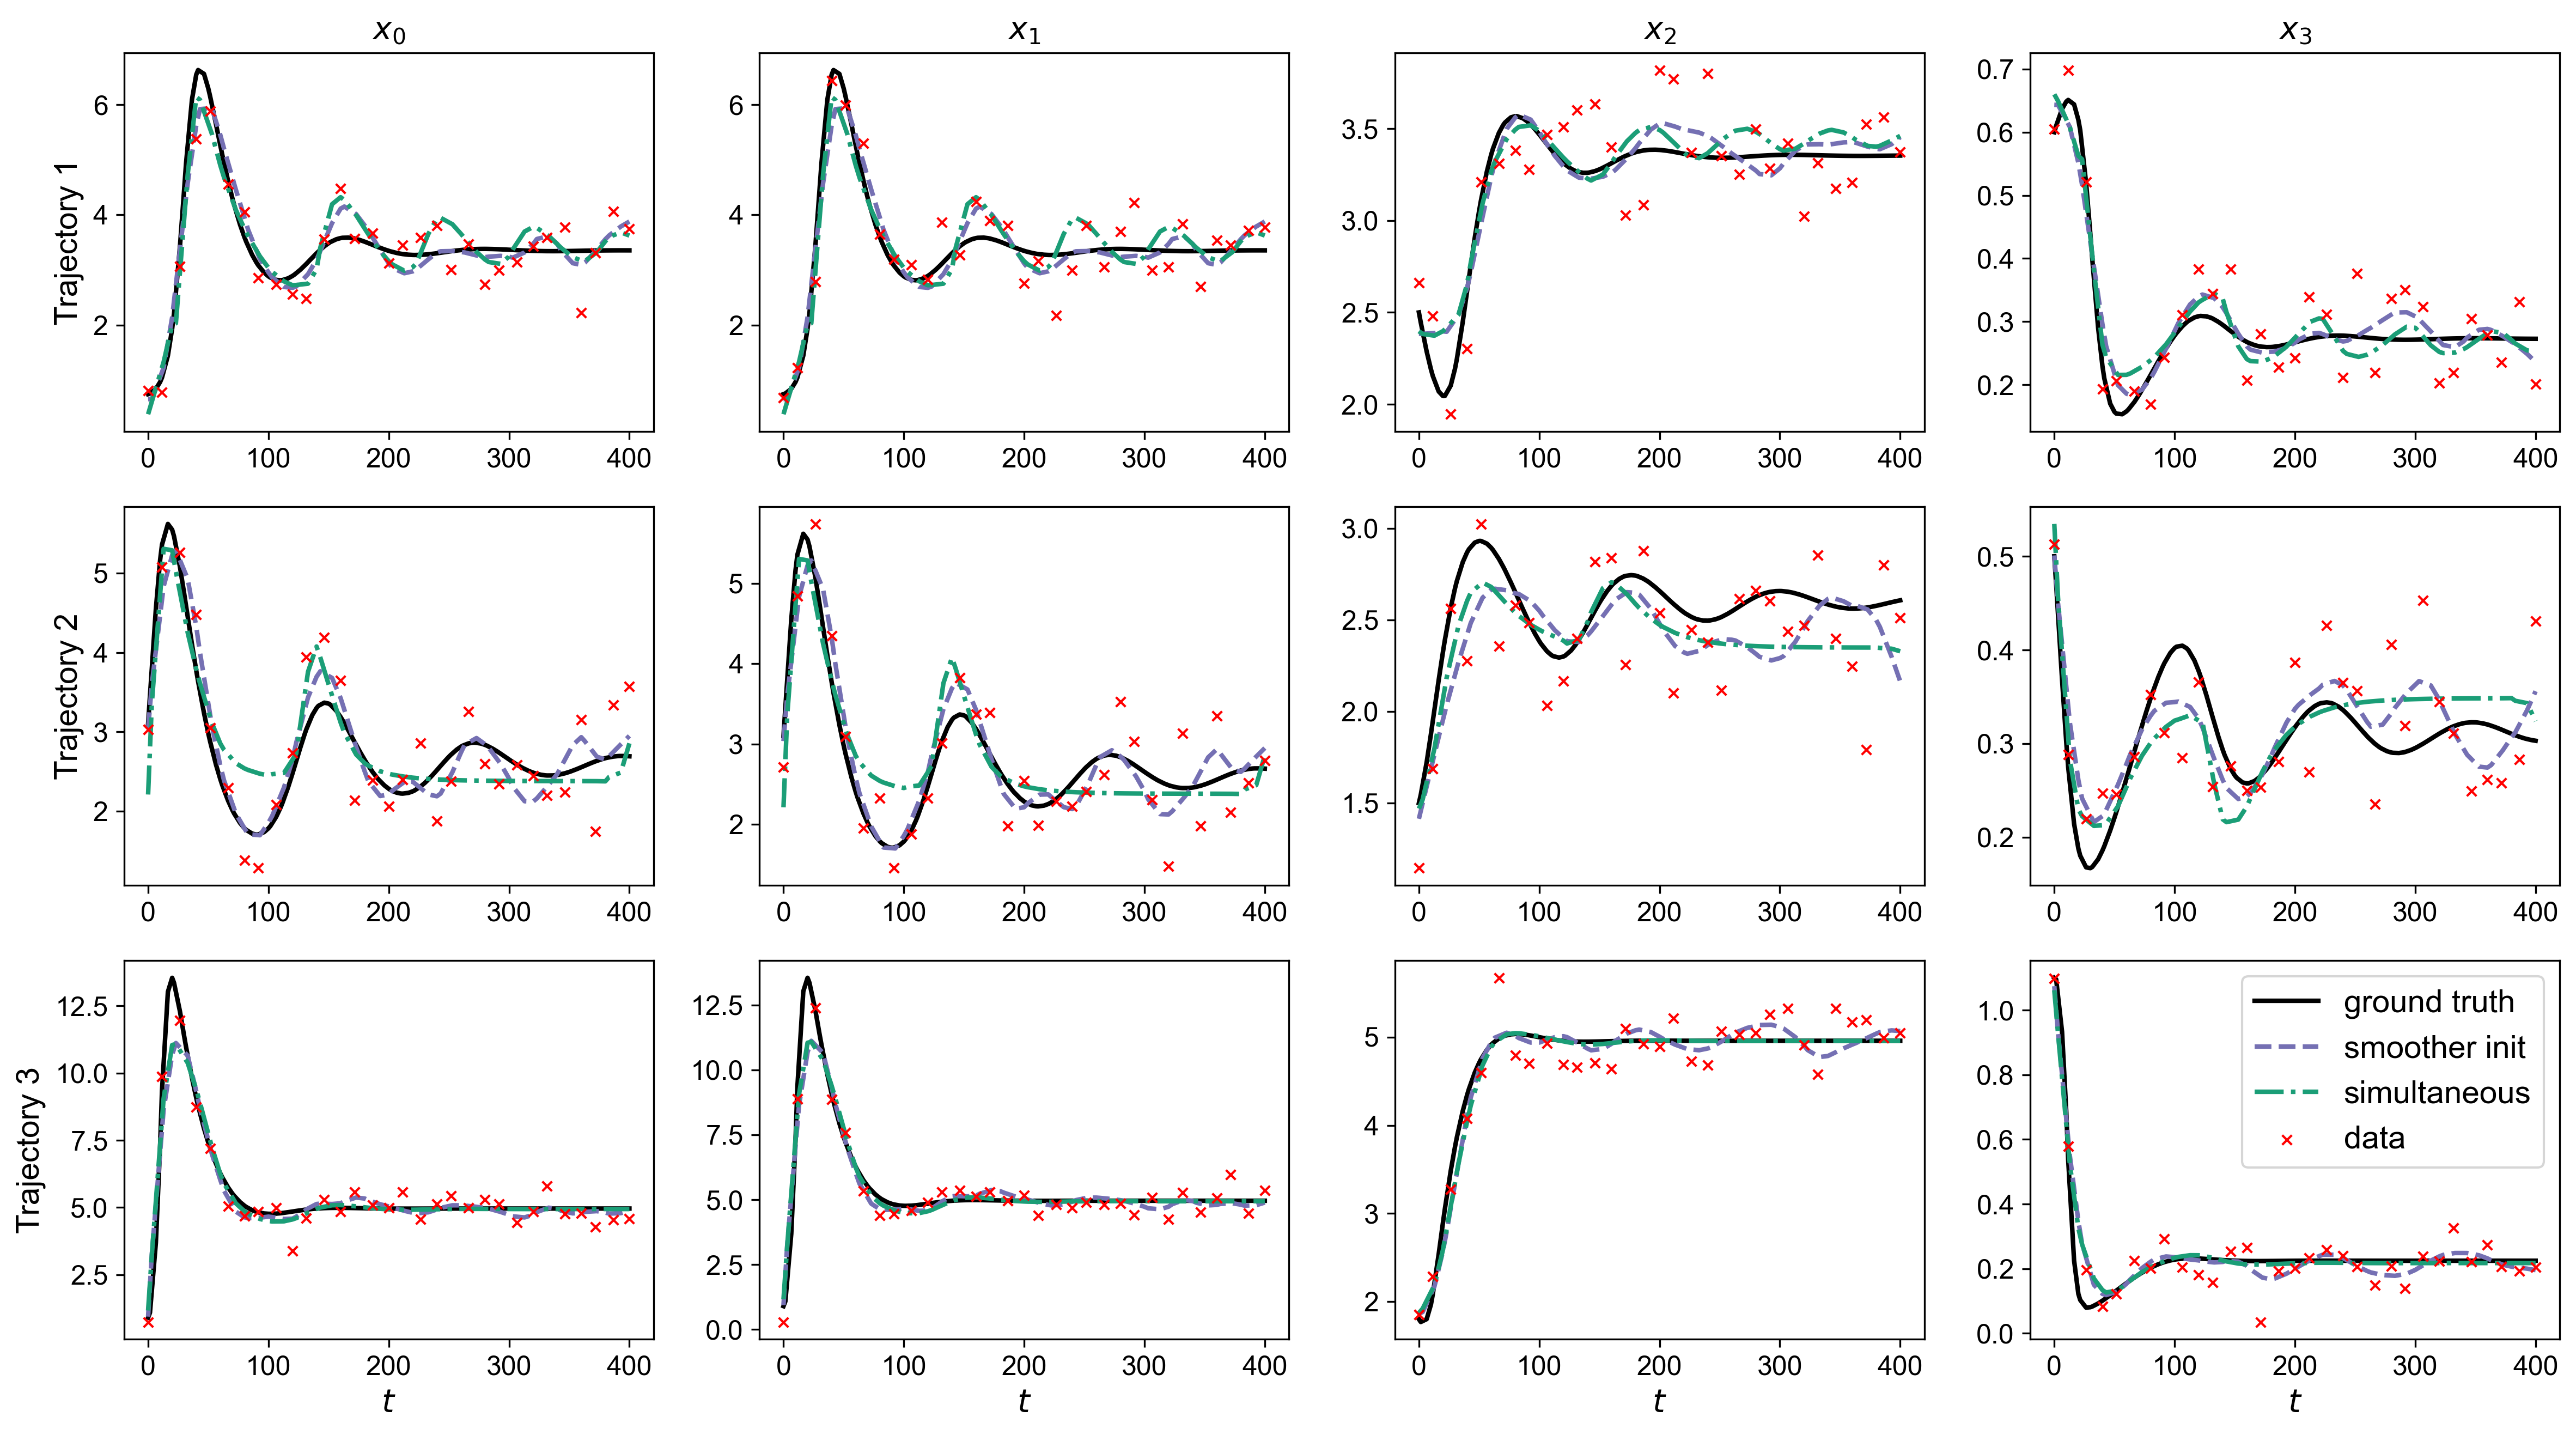

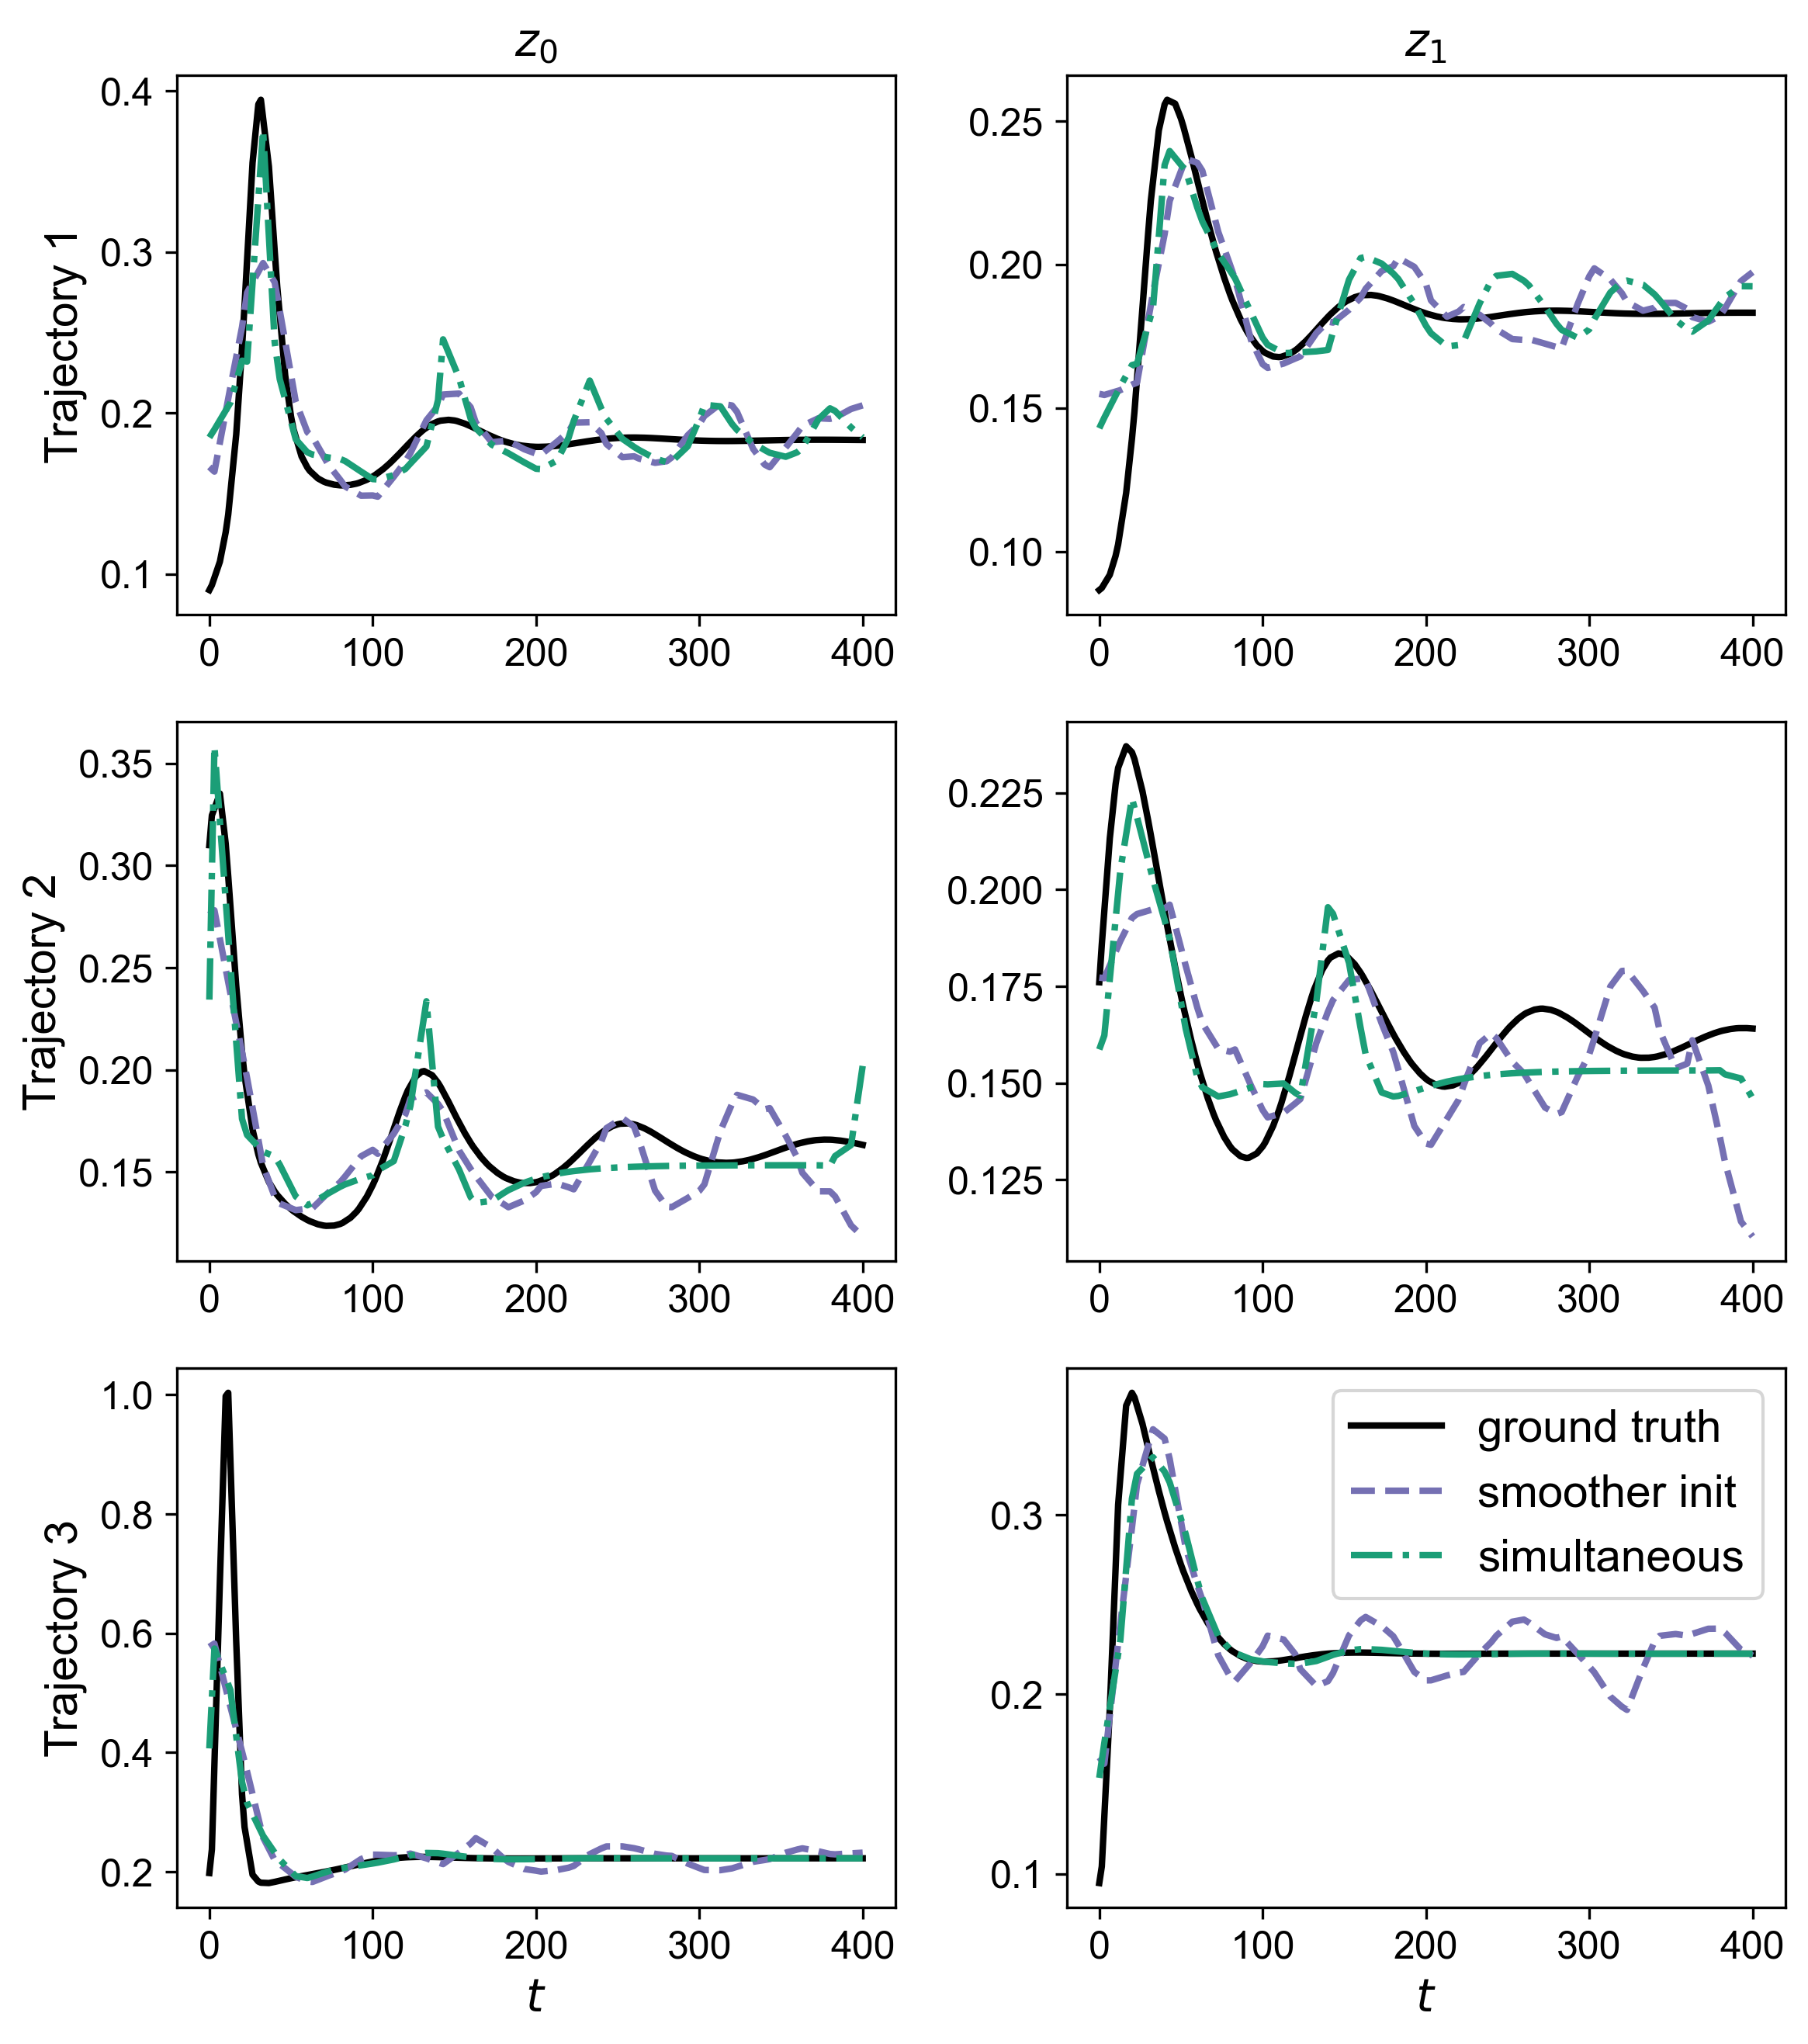

In [ ]:
STATE_NAMES  = ['$x_0$', '$x_1$', '$x_2$', '$x_3$']
OUTPUT_NAMES = ['$z_0$', '$z_1$']

datasets = [
        (true_data,     'ground truth',  {'color': 'black', 'ls': '-'}),
        (smoother_data, 'smoother init', {'color': 'C2',    'ls': '--'}),
        (trained_data,  'simultaneous',  {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_times=problem.obs_times, obs_values=problem.obs_values,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

fig_h, _ = plot_training_history(history)

plt.show()

## Inference using Trained Model

Now that the hybrid model is trained, we can use SiNDAE's inference function helper `solve_inference_model()` to predict trajectories given different initial conditions.

Accordingly, we can set new initial conditions for a new instance of the four tank problem defined above. Other parameters including: the number of discretization points, the number of collocation points, the time span, or the mechanistic parameters can also be altered before doing inference.

In [ ]:
## Validation Trajectory ICs##
FT_VAL_ICS = np.array([[1.10, 1.10, 2.40, 0.90]])

# can also edit the discretization for demonstration
NFE_VAL = 20 
NCP_VAL = 2

val_problem = FourTankProblem(
    params=FT_PARAMS,
    ics=FT_VAL_ICS,         # Validation ICs
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_VAL,            # Validation
    ncp=NCP_VAL,            # Validation
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=FT_ALG_DIM
    )

Since we know the ground truth dynamics for this problem, we can generate a ground truth trajectory to compare the inference result to. Of course, when making predictions on real problems, this is not usually possible. Here, the ground truth curve in intended to serve as a visual reference for hybrid model predictive capacity once trained.

A ground truth curve can be generated using the `generate_data()` function with `noise_std` set to 0 (for each dependent variable).

In [ ]:
## Ground truth for visualisation ##
val_truth = generate_data(
    problem=val_problem, 
    noise_std=np.zeros(4),  # No added noise = ground truth
    obs_every=1,            # Observations = ground truth sampling
    seed=SEED)

generate_data: ok / optimal


Since the Neural Network is trained on data normalized by the mean and standard deviation of the observations, the training prediction data computed by `solve_simultaneous()` should be extracted by `extract_instance_data()` to produce an `InstanceData` object, before being passed to `solve_inference()`. In this example, the training instance data is held in the `trained_data` variable.

By default, `solve_inference()` will use POUNCE to solve the square problem with a hard equality constraint on the NN predictions (slack coefficient of 0.0). However, if this default leads to convergence difficulties, additional $\mathcal{l}_1$ slack can be added to loosen the constraint within reason. See [Inference](../api/inference.md) for more details.

In [ ]:
## Solve the inference problem using trained model ## 
inference_m = solve_inference(
    problem=val_problem,
    mlp=mlp,
    data=trained_data,      # Training results for mean and std stats
    slack_coef=1e-5         # slack
)

## Extract the solution of the validation problem ##
val_results = extract_instance_data(val_problem, inference_m)

=== Building inference model for 1 trajectories (slack_coef=1e-05) ===
=== Solving inference model ===
  Inference: ok / optimal


Plotting similar to the training results above.

<Figure size 1920x1440 with 0 Axes>

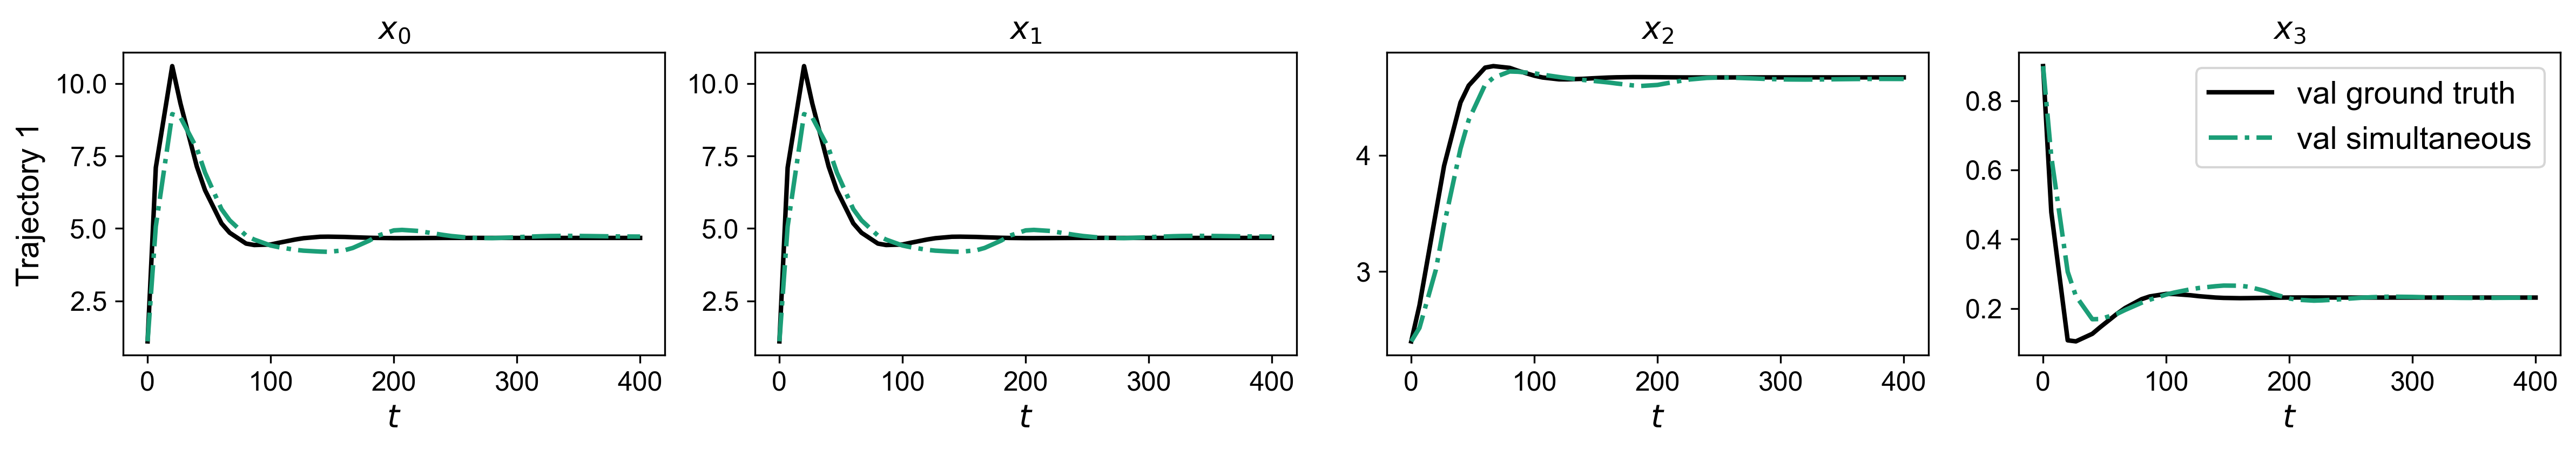

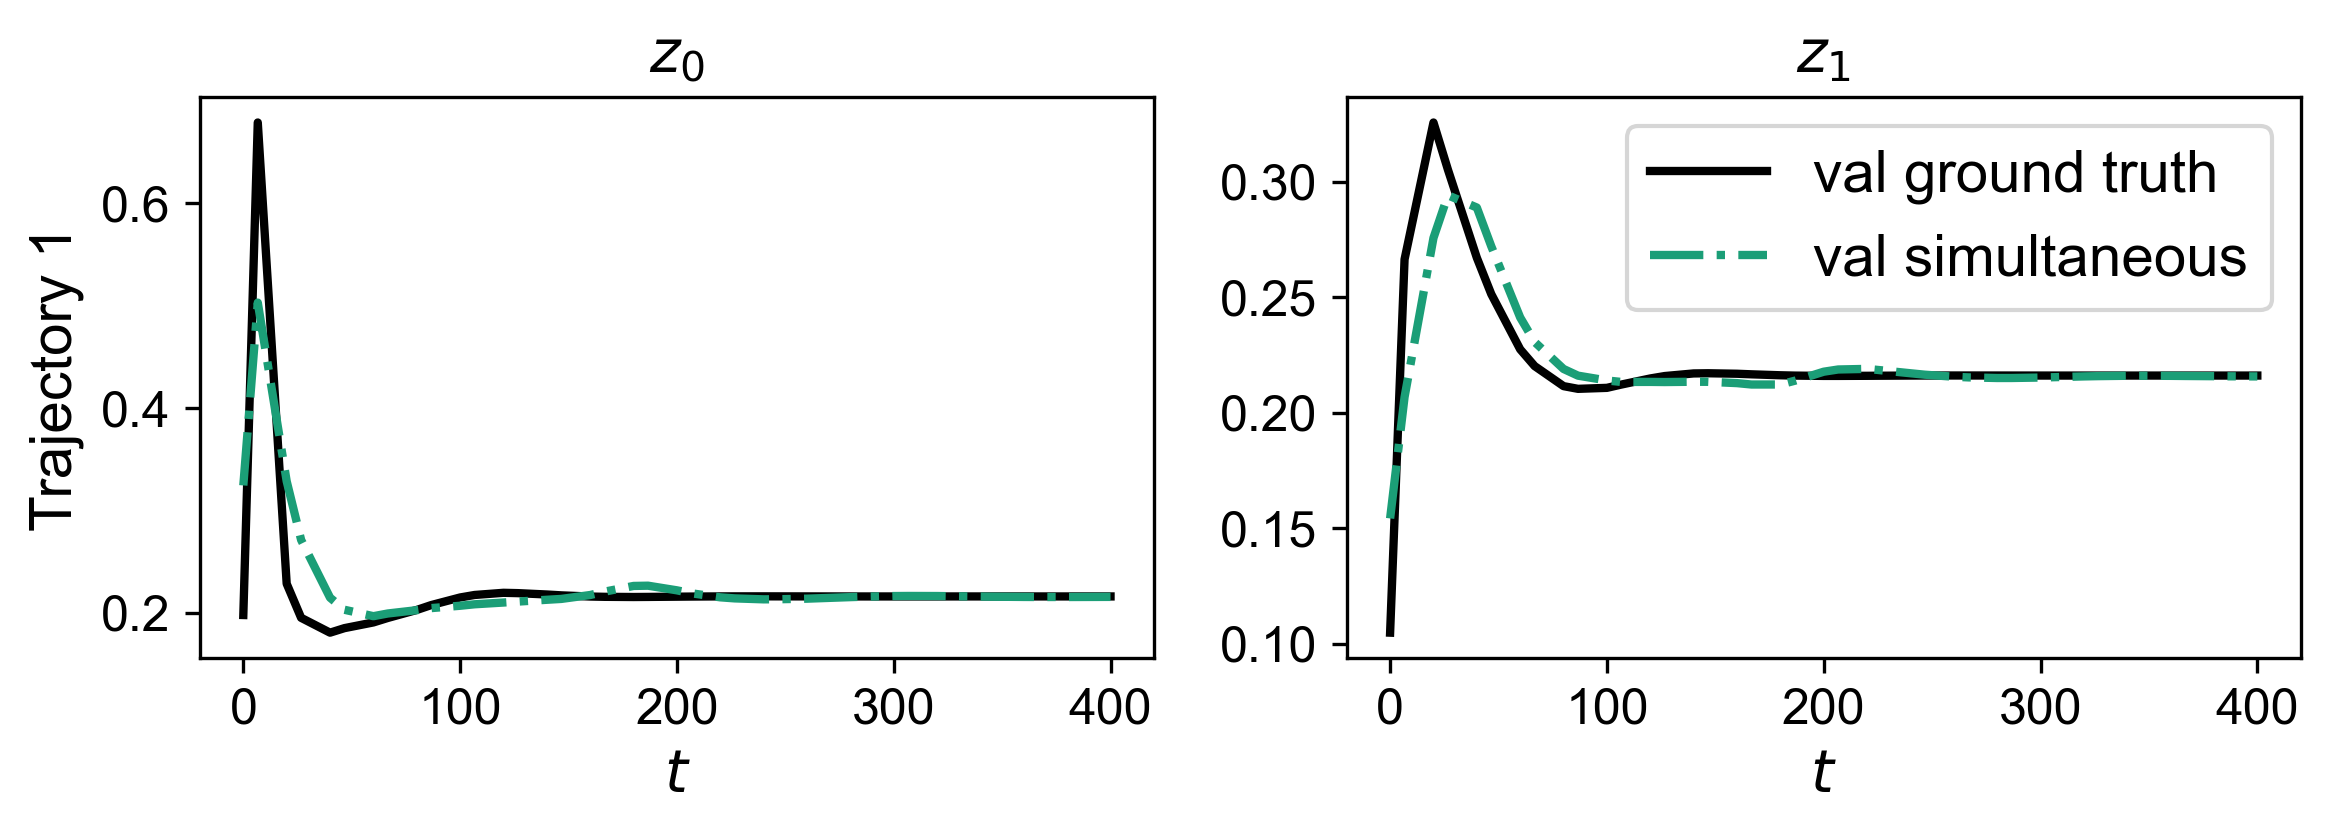

In [ ]:
val_datasets = [
        (val_truth,     'val ground truth',  {'color': 'black', 'ls': '-'}),
        (val_results,   'val simultaneous',  {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

plt.show()

{cite}`lueg2025simultaneous`